In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
pd.set_option('display.max_columns', None)
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [3]:
df = pd.read_csv('Divar.csv')
df_class = pd.read_csv('iran_city_classification.csv')

C:\Users\Toranj\AppData\Local\Temp\ipykernel_21392\1810723204.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Divar.csv')


In [6]:
df.describe()

,Unnamed: 0,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,1000000.000000,3.513220e+05,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,499999.500000,4.102299e+10,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,288675.278932,3.807534e+12,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,249999.750000,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,499999.500000,5.000000e+06,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,749999.250000,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,999999.000000,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000


In [8]:
1.736537e+10 / 4.102299e+10

0.42330824739981165

In [7]:
df

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,NaN,NaN,NaN,سه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,3,یک,NaN,NaN,NaN,True,True,True,۱۳۸۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,NaN,مقطوع,7.500000e+08,False,False,7.500000e+08,NaN,26000000.0,NaN,NaN,132.0,NaN,NaN,3,سه,NaN,NaN,NaN,True,True,True,۱۴۰۱,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,NaN,مقطوع,9.500000e+08,False,False,9.500000e+08,NaN,95000000.0,NaN,NaN,90.0,NaN,NaN,4,یک,NaN,NaN,NaN,True,False,True,۱۴۰۰,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.0,single_page,NaN,4,دو,6,NaN,true,True,True,True,۱۴۰۳,NaN,NaN,package,NaN,NaN,shoofaj,air_conditioner,squat_seat,NaN,NaN,north,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999995,residential-sell,apartment-sell,kermanshah,NaN,2024-07-01 00:00:00,مشاور املاک,~~~مشاورین املاک قبادی~~~\n■جنوبی تک واحدی\n■د...,آپارتمان ۱۸۰ متری وحدت غربی,NaN,NaN,NaN,NaN,مقطوع,7.470000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,NaN,NaN,4.0,چهار,NaN,NaN,NaN,True,True,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.350235,47.083241,500.0
999996,999996,residential-rent,apartment-rent,tehran,darya,2024-07-01 00:00:00,مشاور املاک,نوساز \n\n تک واحدی\n\nشخصی ساز\n\nروف گا...,آپارتمان ۱۱۰ متری سعادت آباد دریا,مقطوع,45000000.0,NaN,rent_credit,NaN,NaN,مقطوع,1.000000e+09,True,True,1.000000e+09,3.000000e+09,45000000.0,100000.0,NaN,110.0,NaN,NaN,1.0,دو,NaN,NaN,NaN,True,True,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [3]:
test_df = df.merge(df_class ,  left_on='city_slug' , right_on='نام شهر' , how='left')

In [5]:
test_df = test_df.drop(columns='نام شهر')

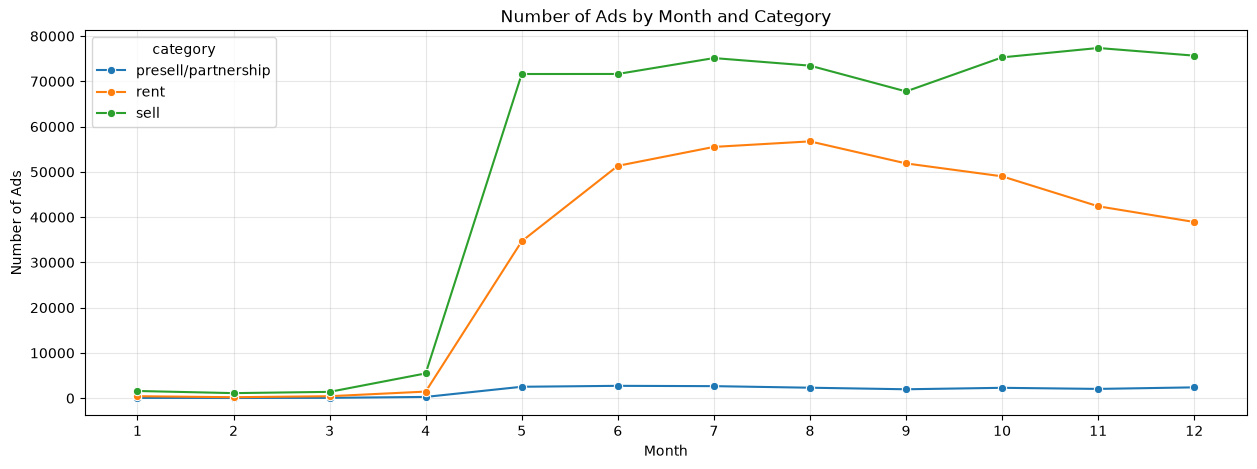

In [74]:
test_df['category'] = test_df['cat2_slug'].str.extract('(rent|sell)')
test_df['category'] = test_df['category'].fillna('presell/partnership')
test_df['created_at_month'] = pd.to_datetime(test_df['created_at_month'])
count = test_df.groupby([test_df['created_at_month'].dt.month, 'category']).size().reset_index(name='count')


plt.figure(figsize=(15, 5))
sns.lineplot(data=count , x='created_at_month' , y='count' , hue='category' , marker='o')
plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Number of Ads')
plt.title('Number of Ads by Month and Category')
plt.grid(alpha=0.3)
plt.show()

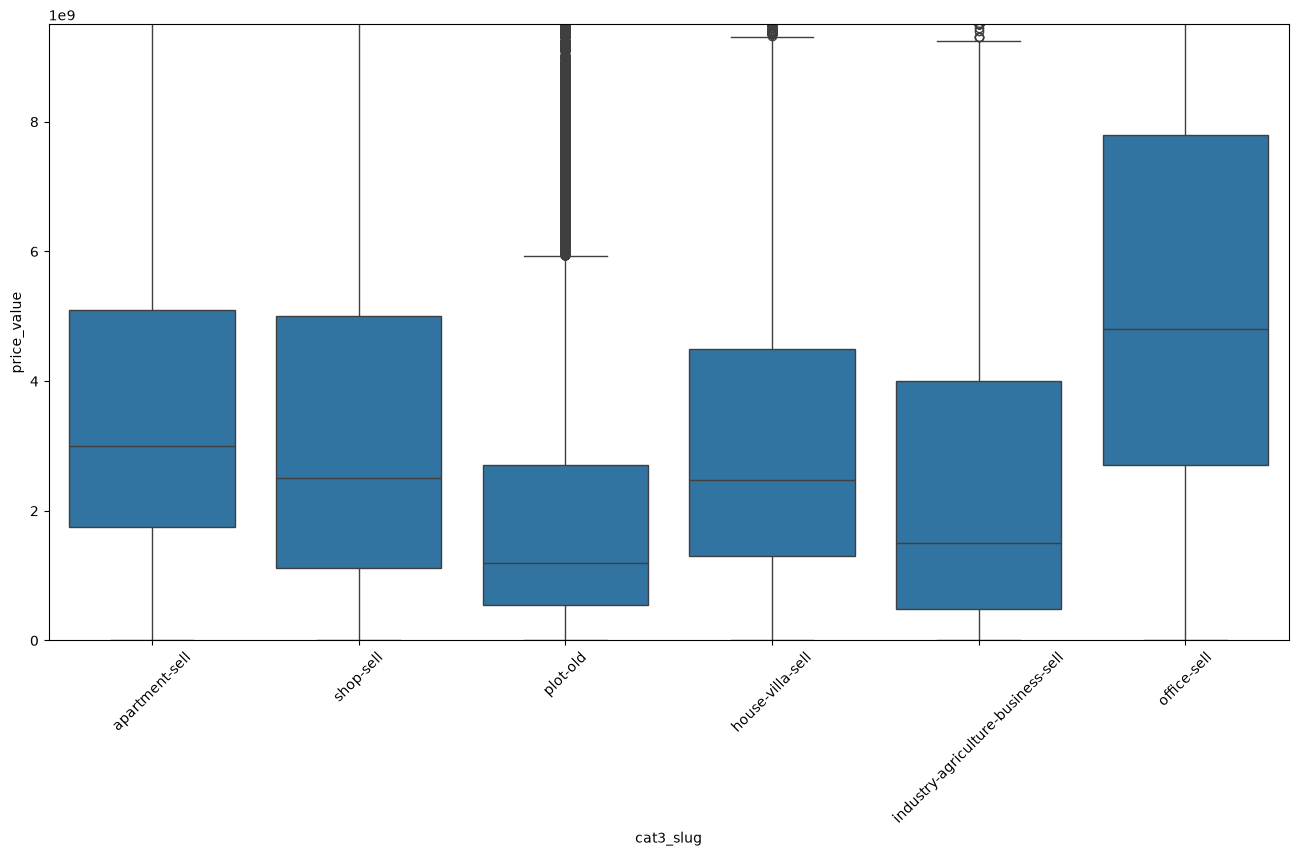

In [ ]:
Q1 = test_df['price_value'].quantile(0.25)
Q3 = test_df['price_value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_normal_1 = test_df[(test_df['price_value'] >= lower) & (test_df['price_value'] <= upper)]


sell_df = df_normal_1[df_normal_1['category'] == 'sell'].copy()
sell_df['price_value'] = pd.to_numeric(sell_df['price_value'] , errors='coerce')
upper = sell_df['price_value'].quantile(0.95)


plt.figure(figsize=(16, 8))
sns.boxplot(data=sell_df , x='cat3_slug' , y='price_value')
plt.ylim(0, upper)
plt.xticks(rotation=45)
plt.xlabel('cat3_slug')
plt.ylabel('price_value')
plt.show()

price_basis
sale           613350
rent_credit    353125
daily_rent      29903
unknown          3622
Name: count, dtype: int64

price_basis                         daily_rent  rent_credit    sale  unknown
cat3_slug                                                                   
apartment-rent                               0       211880       0        0
apartment-sell                               0            0  303385        0
house-villa-rent                             0        64678       0        0
house-villa-sell                             0            0  121753        0
industry-agriculture-business-rent           0         9155       0        0
industry-agriculture-business-sell           0            0   11851        0
office-rent                                  0        21418       0        0
office-sell                                  0            0    5155        0
partnership                                  0            0       0     3622
plot-old                  

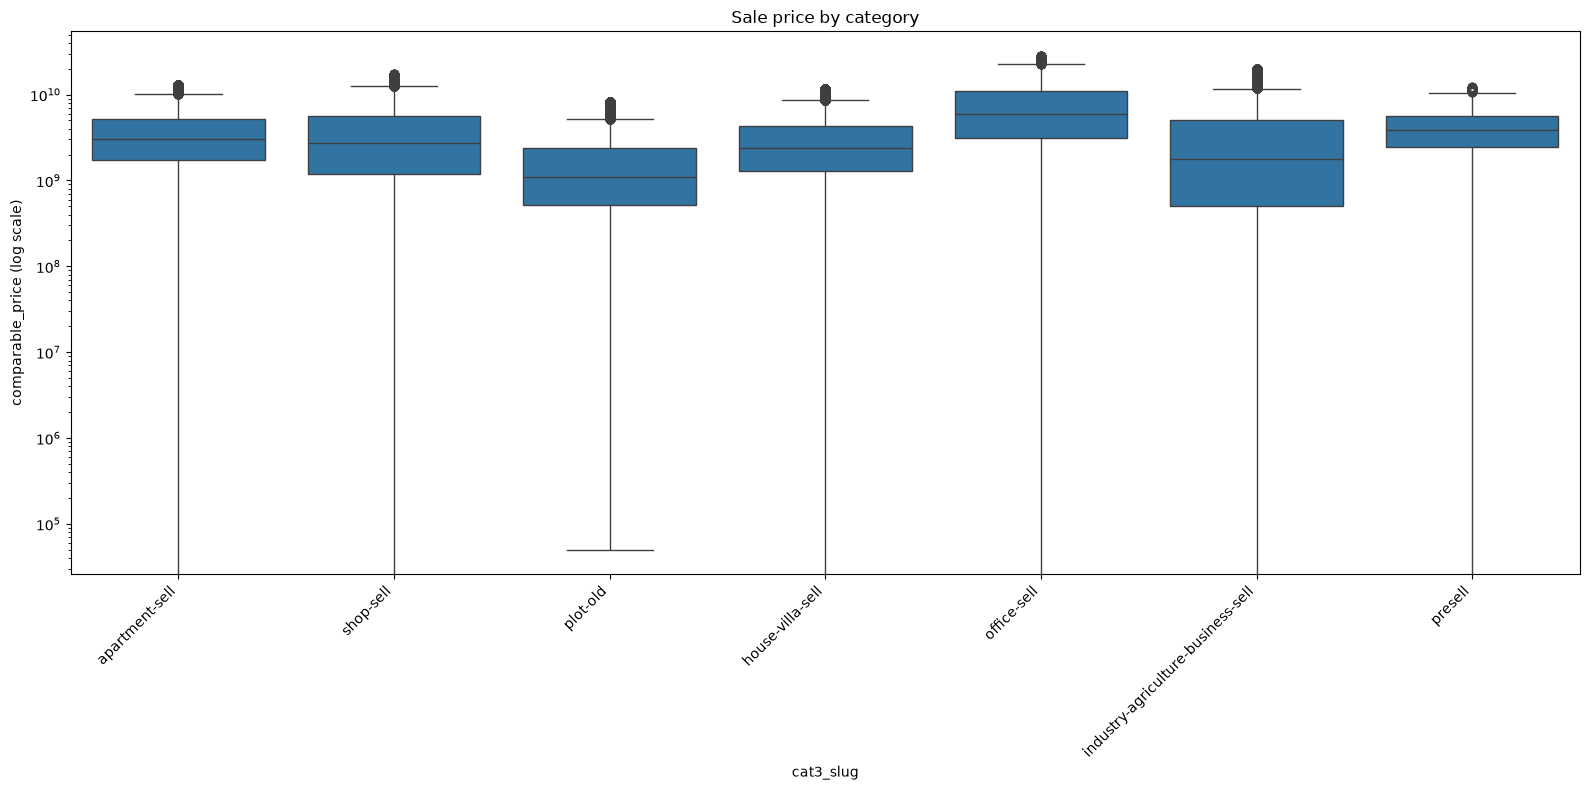

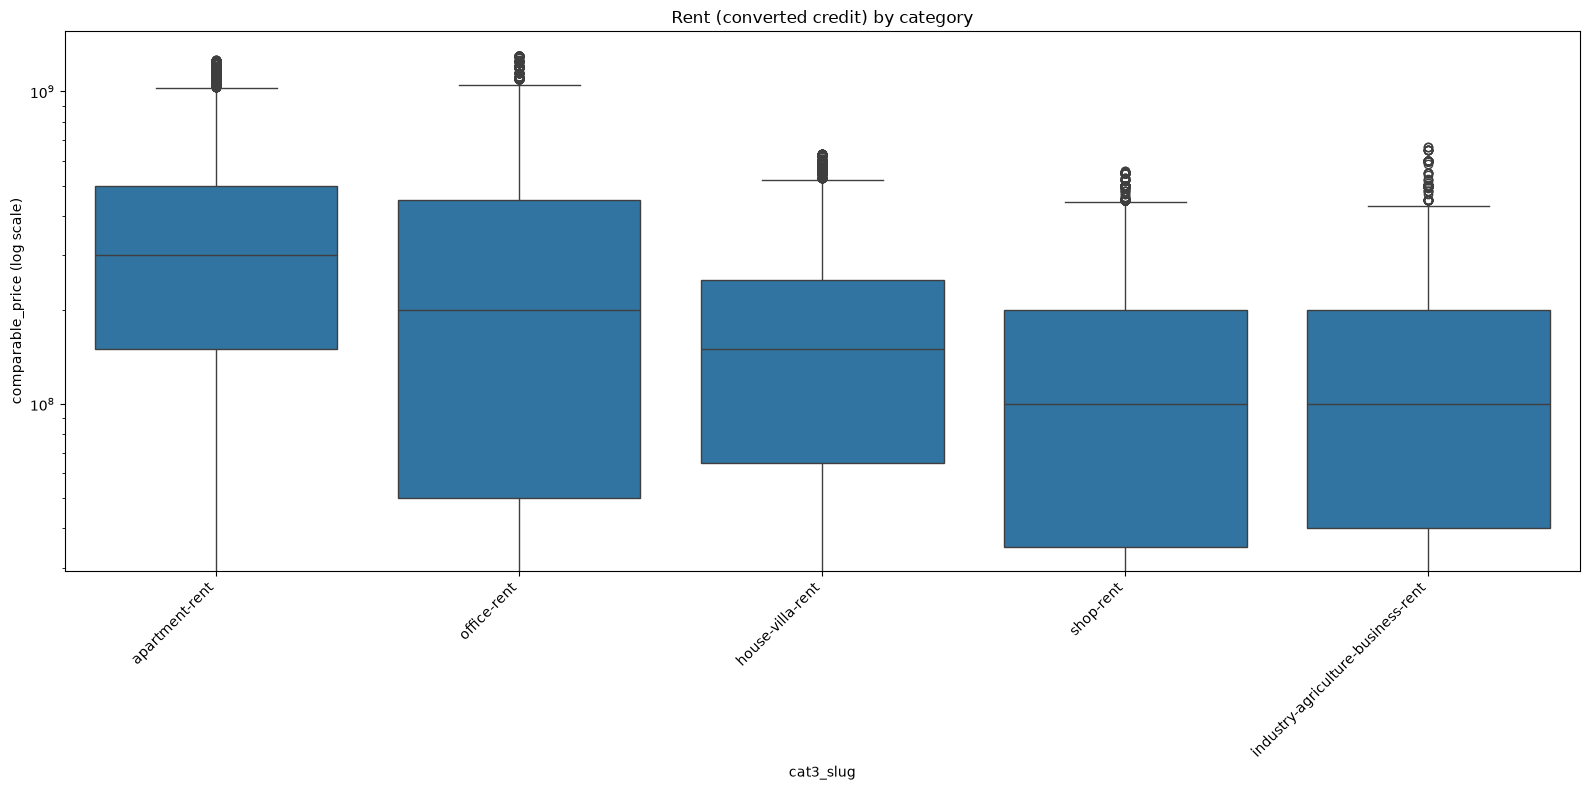

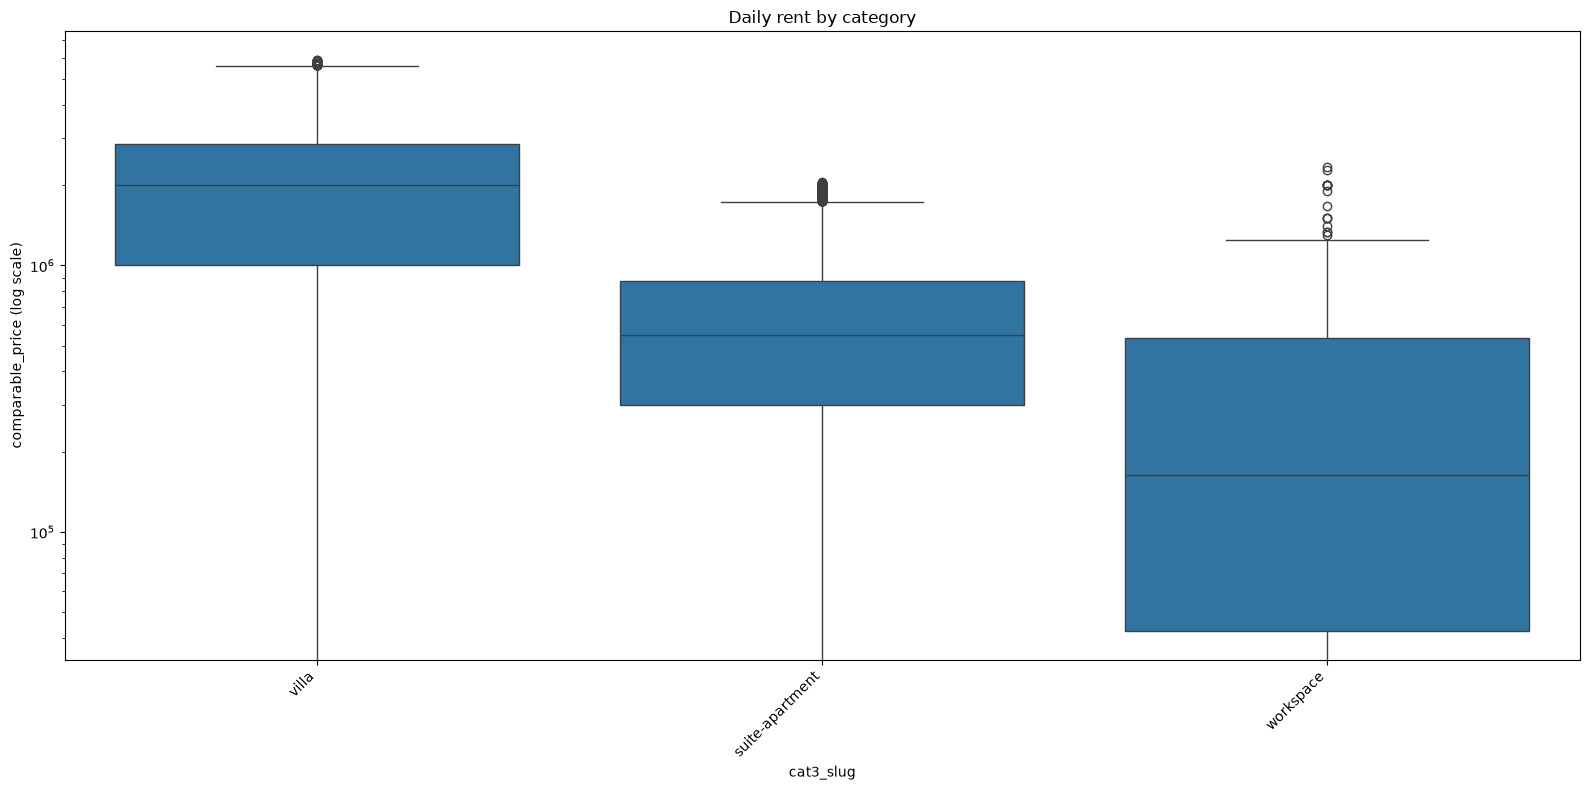

In [ ]:

df_test_1 = df.copy()

def numeric_or_nan(series):

    return series.apply(lambda x: np.nan if isinstance(x, bool) else x).astype(float)

df_test_1['transformable_price_n']  = numeric_or_nan(df_test_1['transformable_price'])
df_test_1['transformable_credit_n'] = numeric_or_nan(df_test_1['transformable_credit'])
df_test_1['transformable_rent_n']   = numeric_or_nan(df_test_1['transformable_rent'])

is_daily = df_test_1['cat2_slug'].eq('temporary-rent')
is_sale  = df_test_1['cat2_slug'].str.endswith('-sell', na=False) | df_test_1['cat3_slug'].isin(['plot-old', 'presell'])
is_rent  = df_test_1['cat2_slug'].str.endswith('-rent', na=False) & ~is_daily

sale_price  = df_test_1['transformable_price_n'].fillna(df_test_1['price_value'])
rent_price  = df_test_1['transformed_credit'].fillna(df_test_1['transformable_credit_n']).fillna(df_test_1['credit_value'])
daily_price = df_test_1[['rent_price_on_regular_days', 'rent_price_on_special_days', 'rent_price_at_weekends']].mean(axis=1)

df_test_1['comparable_price'] = np.select(
    [is_sale, is_rent, is_daily],
    [sale_price, rent_price, daily_price],
    default=np.nan
)
df_test_1['price_basis'] = np.select(
    [is_sale, is_rent, is_daily],
    ['sale', 'rent_credit', 'daily_rent'],
    default='unknown'
)

df_test_1['comparable_price'] = pd.to_numeric(df_test_1['comparable_price'], errors='coerce')

print(df_test_1['price_basis'].value_counts())
print()
print(pd.crosstab(df_test_1['cat3_slug'], df_test_1['price_basis']))
print()
print(df_test_1.groupby('price_basis')['comparable_price'].describe())


def iqr_filter_per_group(df, group_col, value_col, k=1.5, min_group_size=5):
    """Remove outliers using IQR computed within each group separately."""
    df = df.dropna(subset=[value_col]).copy()

    counts = df[group_col].value_counts()
    valid_groups = counts[counts >= min_group_size].index
    df = df[df[group_col].isin(valid_groups)]

    q1 = df.groupby(group_col)[value_col].transform('quantile', 0.25)
    q3 = df.groupby(group_col)[value_col].transform('quantile', 0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr

    mask = df[value_col].between(lower, upper)
    return df[mask].copy()



def plot_by_category(df, basis, min_group_size=200, k=1.5, title=None):
    sub = df[df['price_basis'] == basis].copy()
    if sub.empty:
        print(f"No rows found for price_basis == '{basis}'")
        return

    sub_clean = iqr_filter_per_group(sub, 'cat3_slug', 'comparable_price',
                                      k=k, min_group_size=min_group_size)
    if sub_clean.empty:
        print(f"'{basis}': all rows removed by filtering — check min_group_size / k")
        return

    plt.figure(figsize=(16, 8))
    sns.boxplot(data=sub_clean, x='cat3_slug', y='comparable_price')
    plt.yscale('log')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('cat3_slug')
    plt.ylabel('comparable_price (log scale)')
    plt.title(title or f'{basis} price distribution by category')
    plt.tight_layout()
    plt.show()

    return sub_clean


sale_clean = plot_by_category(df_test_1, 'sale',        title='Sale price by category')
rent_clean = plot_by_category(df_test_1, 'rent_credit',  title='Rent (converted credit) by category')
daily_clean = plot_by_category(df_test_1, 'daily_rent',  min_group_size=30, title='Daily rent by category')

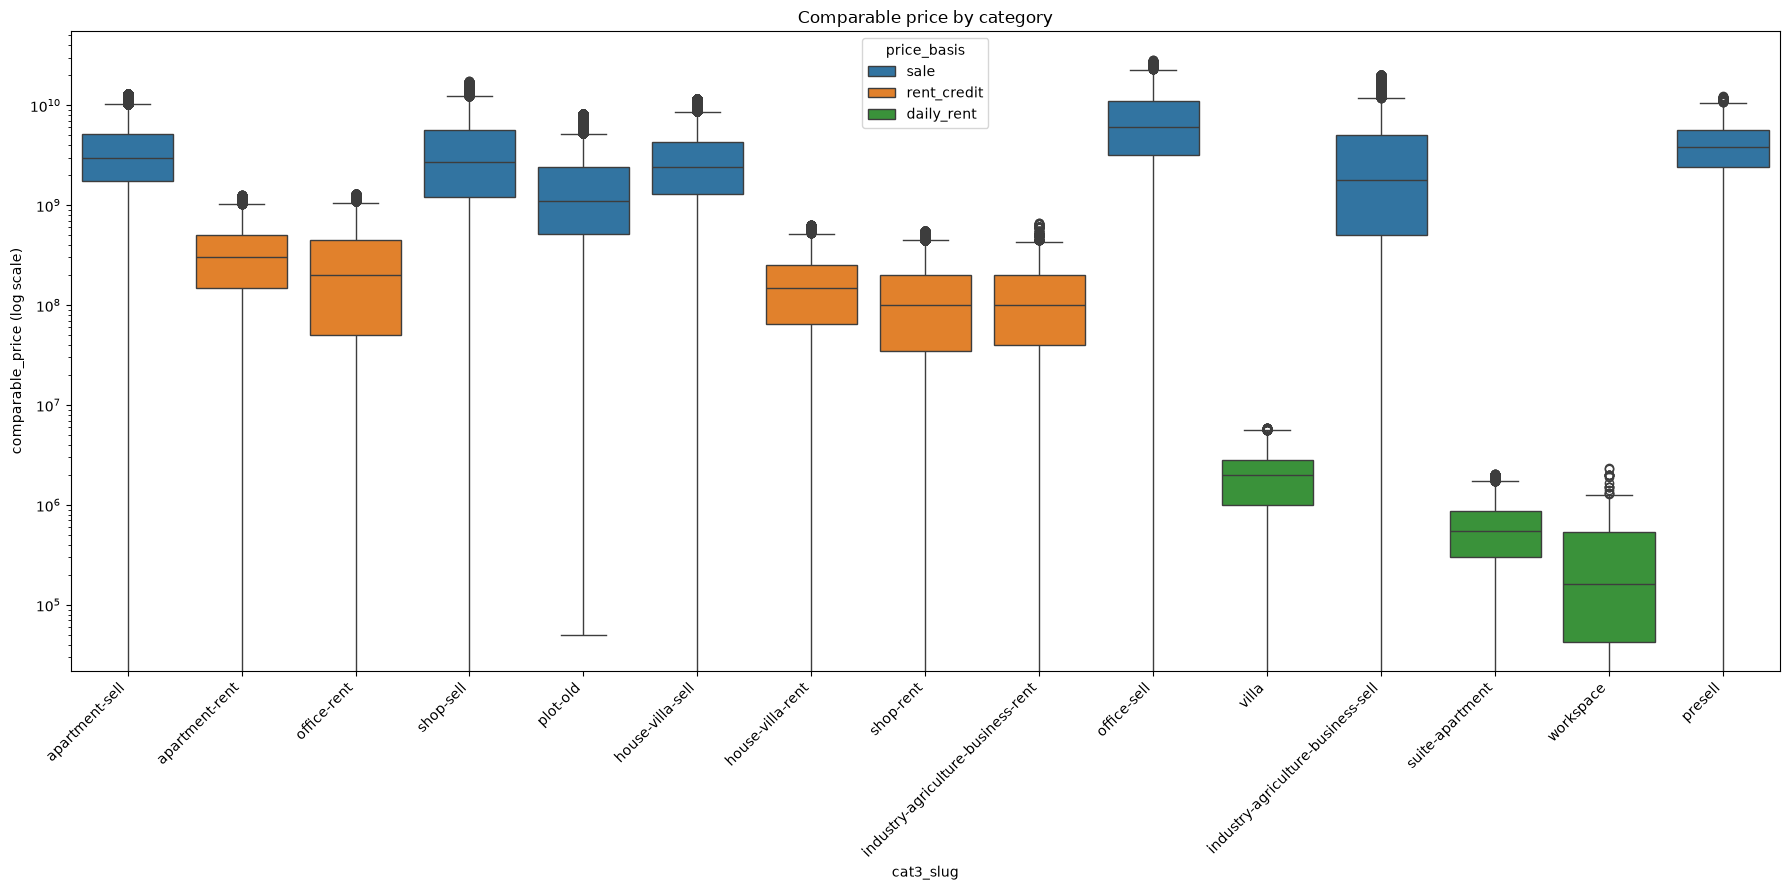

In [115]:
sub = df_test_1.dropna(subset=['comparable_price']).copy()
sub_clean = iqr_filter_per_group(sub, 'cat3_slug', 'comparable_price', min_group_size=50)

plt.figure(figsize=(18, 9))
sns.boxplot(data=sub_clean, x='cat3_slug', y='comparable_price', hue='price_basis', dodge=False)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.xlabel('cat3_slug')
plt.ylabel('comparable_price (log scale)')
plt.title('Comparable price by category')
plt.legend(title='price_basis')
plt.tight_layout()
plt.show()

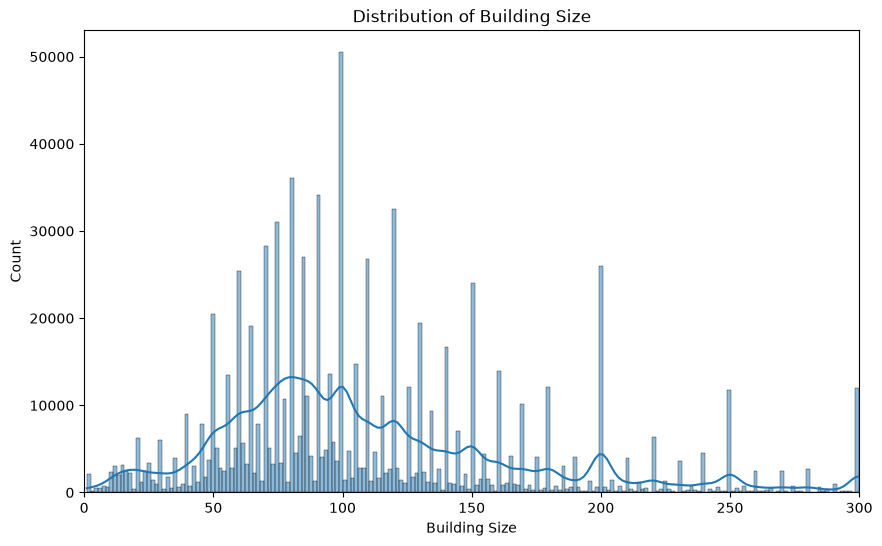

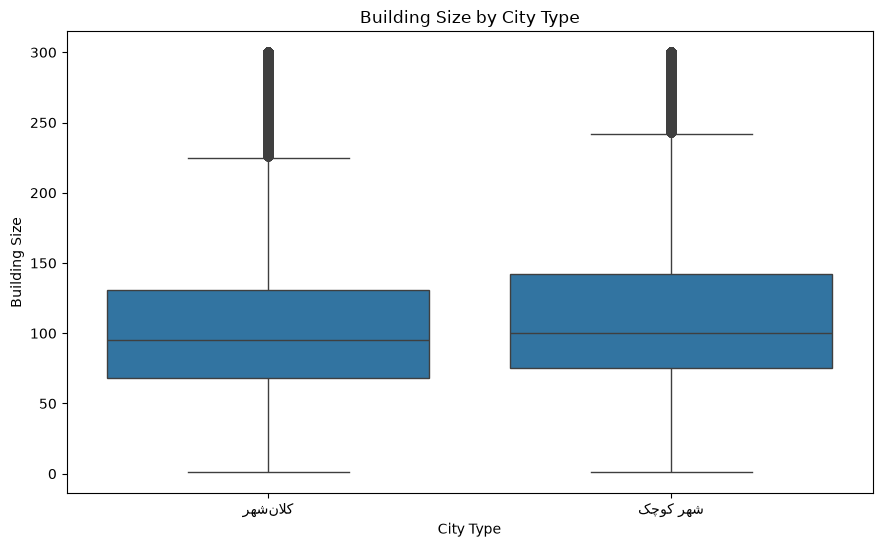

Big Cities mean: 105.78480441728743
Small Cities mean: 114.02356525319061
t-statistic: -64.62808414970104
p-value: 0.0


In [77]:
Q1 = test_df['building_size'].quantile(0.25)
Q3 = test_df['building_size'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_normal = test_df[(test_df['building_size'] >= lower) & (test_df['building_size'] <= upper)]



plt.figure(figsize=(10, 6))
sns.histplot(df_normal['building_size'] , kde=True)
plt.xlabel('Building Size')
plt.ylabel('Count')
plt.title('Distribution of Building Size')
plt.xlim(0, 300)
plt.show()

plt.figure(figsize=(10.4, 6))
sns.boxplot(data=df_normal , x='دسته‌بندی' , y='building_size')
plt.xlabel('City Type')
plt.ylabel('Building Size')
plt.title('Building Size by City Type')
plt.show()



big_cities = df_normal[df_normal['دسته‌بندی'] == 'کلان‌شهر']['building_size'].dropna()
small_cities = df_normal[df_normal['دسته‌بندی'] == 'شهر کوچک']['building_size'].dropna()
# t test welch 
# H0 => Ubigcities >= Usmallcities
# H1 => Ubigcities < Usamllcities
# p < 0.05 ==> so H0 get rejected and the p value supports H1
t_stat, p_value = ttest_ind(big_cities , small_cities , equal_var=False , alternative='less')
print('Big Cities mean:', big_cities.mean())
print('Small Cities mean:', small_cities.mean())
print('t-statistic:', t_stat)
print('p-value:', p_value)

In [55]:

u_stat, p_value = mannwhitneyu(big_cities , small_cities , alternative='less')
print('U statistic:', u_stat)
print('p-value:', p_value)

U statistic: 83409861392.0
p-value: 0.0
